<div dir="rtl">
  <p style="color: #80f9fa; text-align: right;">
    <b>معرفی دیتاست و دیتالودر در تورچ</b>
  </p>
</div>

---

! pip install torch torchvision

<div dir="rtl" style="text-align: right;">
راه‌های ساخت دیتاست:

- استفاده از مجموعه داده‌های شخصی
- استفاده از مجموعه داده‌های عمومی/پیش‌فرض تورچ
</div>

<div dir="rtl" style="text-align: right;">
وجود برخی مجموعه داده‌های پیش‌فرض در ماژول torchvision:

https://pytorch.org/vision/stable/datasets.html
</div>

<div dir="rtl" style="text-align: right;">
کلاس‌های اصلی مرتبط با داده برای استفاده در شبکه‌های عصبی:

- torch.utils.data.Dataset
- torch.utils.data.DataLoader
- from torchvision import datasets
</div>

---

<div dir="rtl">
  <p style="color: #80f9fa; text-align: right;">
    <b>الف- استفاده از دیتاست پیش‌فرض</b>
  </p>
</div>

<div dir="rtl" style="text-align: right;">
ساخت دیتاست:
</div>

In [179]:
from torchvision import datasets
from torchvision.transforms import ToTensor


training_data = datasets.FashionMNIST(
    root="../data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="../data",
    train=False,
    download=True,
    transform=ToTensor()
)

In [180]:
from torchvision.datasets import Flowers102

train_dataset = Flowers102(
    root="../data",
    split="train",
    download=True
)

val_dataset = Flowers102(
    root="../data",
    split="val",
    download=True
)

test_dataset = Flowers102(
    root="../data",
    split="test",
    download=True
)

<div dir="rtl" style="text-align: right;">
جداکردن داده‌ی اعتبارسنجی:
</div>

In [181]:
from torch.utils.data import random_split

train_size = int(0.9 * len(training_data))
train_data, val_data = random_split(training_data, [train_size, len(training_data) - train_size])

<div dir="rtl" style="text-align: right;">
مشاهده تصاویر برخی داده‌ها:
</div>

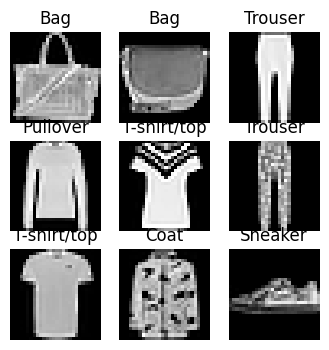

In [182]:
import torch
import matplotlib.pyplot as plt

labels_map = {v: k for k, v in training_data.class_to_idx.items()}

figure = plt.figure(figsize=(4, 4))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

<div dir="rtl" style="text-align: right;">
دسترسی به داده‌ها و برچسب‌ها:
</div>

In [183]:
img, label = training_data[0]
print("type: ", type(img))
print("shape: ", img.shape)
print("label:", label, "-", training_data.classes[label])

type:  <class 'torch.Tensor'>
shape:  torch.Size([1, 28, 28])
label: 9 - Ankle boot


In [184]:
X = training_data.data
Y = training_data.targets
print(X.shape)
print(Y.shape)

torch.Size([60000, 28, 28])
torch.Size([60000])


<div dir="rtl" style="text-align: right;">
سوال:
شماره برچسب داده‌ی پنجم تست چند است و کدام کلاس است؟
</div>

In [185]:
img, label = test_data[5]
print("type: ", type(img))
print("shape: ", img.shape)
print("label: ", label, "-", training_data.classes[label])

type:  <class 'torch.Tensor'>
shape:  torch.Size([1, 28, 28])
label:  1 - Trouser


<div dir="rtl" style="text-align: right;">
بررسی وضعیت داده‌ها اعم از تعداد داده و کلاس برچسب‌ها:
</div>

In [186]:
print("len(train): ", len(training_data))
print("len(test): ", len(test_data))

len(train):  60000
len(test):  10000


In [187]:
print(training_data.classes)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [188]:
labels_map = {v: k for k, v in training_data.class_to_idx.items()}
print(labels_map)

{0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat', 5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'}


<div dir="rtl" style="text-align: right;">
سوال:
به ازای هر کلاس در داده‌ی آموزش چه تعدادی داده داریم؟ آیا تعداد داده‌ها در هر کلاس متعادل است؟
</div>

In [189]:
from collections import Counter
for k,v in Counter(training_data.targets.tolist()).items():
    print(labels_map[k], v)

Ankle boot 6000
T-shirt/top 6000
Dress 6000
Pullover 6000
Sneaker 6000
Sandal 6000
Trouser 6000
Shirt 6000
Coat 6000
Bag 6000


<div dir="rtl" style="text-align: right;">
تمرین: جمع‌بندی مبحث استفاده از داده‌های پیش‌فرض کتابخانه دیتاست
(بندهای اول و سوم)

- داده‌ی MNIST را از کتابخانه دیتاست بخوانید.
- تعداد داده‌های آموزش و تست را چاپ نمایید.
- اسامی کلاس‌های داده را چاپ نمایید.
- ۲۵ تصویر تصادفی از مجموعه داده آموزش به همراه برچسب نظیرشان (مشابه کد فوق) را نمایش دهید.
</div>

In [190]:
from torchvision import datasets
from torchvision.transforms import ToTensor


training_data = datasets.MNIST(
    root="../data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.MNIST(
    root="../data",
    train=False,
    download=True,
    transform=ToTensor()
)

In [191]:
print("len(train): ", len(training_data))
print("len(test): ", len(test_data))

len(train):  60000
len(test):  10000


In [192]:
labels_map = {v: k for k, v in training_data.class_to_idx.items()}
print(labels_map)

{0: '0 - zero', 1: '1 - one', 2: '2 - two', 3: '3 - three', 4: '4 - four', 5: '5 - five', 6: '6 - six', 7: '7 - seven', 8: '8 - eight', 9: '9 - nine'}


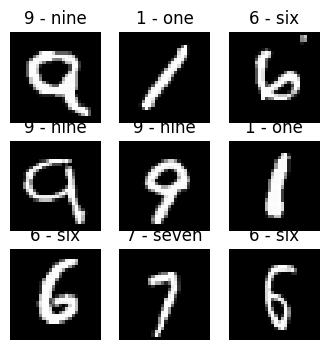

In [193]:
import torch
import matplotlib.pyplot as plt

labels_map = {v: k for k, v in training_data.class_to_idx.items()}

figure = plt.figure(figsize=(4, 4))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

---

<div dir="rtl">
  <p style="color: #80f9fa; text-align: right;">
    <b>ب- ساخت دیتاست سفارشی</b>
  </p>
</div>

<div dir="rtl" style="text-align: right;">
اهمیت ارث‌بری از کلاس dataset و بازنویسی توابع زیر:

- __init__: برای مقداردهی اولیه کلاس.
- __len__: برای تعیین طول دیتاست (تعداد نمونه‌ها).
- __getitem__: برای دسترسی به هر نمونه از دیتاست (معمولاً تصاویر و برچسب‌ها).
</div>

<div dir="rtl" style="text-align: right;">
اسکریپت ذخیره‌ی مجزای تصاویر FashionMNIST در مسیر فعلی به همراه لیبل‌ها
</div>

In [194]:
# import os
# import pandas as pd
# from torchvision import datasets

# train_data = datasets.FashionMNIST(root='../data', train=True, download=True, transform=None)

# img_dir = '../data/FashionMNIST/images'
# os.makedirs(img_dir, exist_ok=True)

# annotations = []

# for idx in range(len(train_data)):
#     img, label = train_data[idx]
#     img_name = f"{idx}.png"
#     img.save(os.path.join(img_dir, img_name))
#     annotations.append([img_name, label])

# annotations_df = pd.DataFrame(annotations, columns=['image_name', 'label'])
# annotations_df.to_csv('../data/FashionMNIST/annotations.csv', index=False)

In [195]:
import pandas as pd
pd.read_csv('../data/FashionMNIST/annotations.csv')

,image_name,label
0,0.png,9
1,1.png,0
2,2.png,0
3,3.png,3
4,4.png,0
...,...,...
59995,59995.png,5
59996,59996.png,1
59997,59997.png,3
59998,59998.png,0


In [196]:
import os
import pandas as pd
from torchvision.io import read_image
from torch.utils.data import Dataset

class CustomImageDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = read_image(img_path)
        label = self.img_labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        return image, label

In [197]:
custom_dataset = CustomImageDataset(annotations_file="../data/FashionMNIST/annotations.csv", img_dir="../data/FashionMNIST/images")
print(len(custom_dataset))

60000


In [198]:
image, label = custom_dataset[0]
print(type(image), image.shape)
print(label)

<class 'torch.Tensor'> torch.Size([1, 28, 28])
9


---

<div dir="rtl">
  <p style="color: #80f9fa; text-align: right;">
    <b>ج- آماده‌سازی دیتالودر</b>
  </p>
</div>

In [199]:
from torchvision import datasets
from torchvision.transforms import ToTensor


training_data = datasets.FashionMNIST(
    root="../data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="../data",
    train=False,
    download=True,
    transform=ToTensor()
)

In [200]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=False)

In [201]:
for img, label in train_dataloader:
    print(img.shape)
    print(label)
    break

torch.Size([64, 1, 28, 28])
tensor([8, 2, 3, 0, 5, 3, 0, 0, 9, 3, 8, 9, 1, 6, 7, 3, 7, 8, 1, 0, 5, 4, 8, 3,
        3, 6, 8, 4, 5, 2, 1, 1, 9, 9, 4, 4, 9, 0, 5, 9, 0, 2, 3, 6, 4, 9, 4, 8,
        7, 2, 3, 8, 0, 1, 3, 7, 9, 2, 9, 1, 1, 7, 7, 0])


<div dir="rtl" style="text-align: right;">
سوال:
دیتالودر تست را دو مرحله متوالی فراخوانی نموده و وضعیت برچسب‌ها را مقایسه نمایید. آیا ترتیب داده‌ها محفوظ است؟
</div>

In [202]:
for img, label in test_dataloader:
    print(img.shape)
    print(label)
    break

torch.Size([64, 1, 28, 28])
tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7, 4, 5, 7, 3, 4, 1, 2, 4, 8, 0, 2, 5, 7, 9,
        1, 4, 6, 0, 9, 3, 8, 8, 3, 3, 8, 0, 7, 5, 7, 9, 6, 1, 3, 7, 6, 7, 2, 1,
        2, 2, 4, 4, 5, 8, 2, 2, 8, 4, 8, 0, 7, 7, 8, 5])


In [203]:
for img, label in test_dataloader:
    print(img.shape)
    print(label)
    break

torch.Size([64, 1, 28, 28])
tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7, 4, 5, 7, 3, 4, 1, 2, 4, 8, 0, 2, 5, 7, 9,
        1, 4, 6, 0, 9, 3, 8, 8, 3, 3, 8, 0, 7, 5, 7, 9, 6, 1, 3, 7, 6, 7, 2, 1,
        2, 2, 4, 4, 5, 8, 2, 2, 8, 4, 8, 0, 7, 7, 8, 5])


<div dir="rtl" style="text-align: right;">
سوال:
فراوانی هر کلاس را به ازای اولین بچ از دیتالودر ترین و تست محاسبه نمایید.
</div>

In [204]:
for img, label in test_dataloader:
    print(img.shape)
    print(Counter(label.tolist()))
    break

torch.Size([64, 1, 28, 28])
Counter({7: 9, 2: 8, 4: 8, 8: 8, 1: 7, 5: 6, 6: 5, 3: 5, 9: 4, 0: 4})


<div dir="rtl" style="text-align: right;">
تمرین: جمع‌بندی مبحث استفاده از دیتالودر
(بندهای اول تا سوم)

- داده‌ی MNIST را از کتابخانه دیتاست بخوانید.
- ده درصد داده‌های آموزش را به عنوان داده اعتبارسنجی جدا نمایید.
- دیتالودر متناسب با این داده را برای سه مجموعه داده‌ی آموزش، تست و ارزیابی به ازای سایز بچ ۳۲ بسازید.
- ابعاد تصاویر و هم‌چنین فراوانی برچسب‌های کلاس را به ازای اولین بچ از داده آموزش، ارزیابی و اعتبارسنجی چاپ نمایید.
</div>

In [205]:
from torch.utils.data import random_split
from torchvision import datasets
from torchvision.transforms import ToTensor


training_data = datasets.MNIST(
    root="../data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.MNIST(
    root="../data",
    train=False,
    download=True,
    transform=ToTensor()
)

train_size = int(0.9 * len(training_data))
train_data, val_data = random_split(training_data, [train_size, len(training_data) - train_size])

In [206]:
len(train_data),len(val_data),len(test_data)

(54000, 6000, 10000)

In [207]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=32, shuffle=False)
test_dataloader = DataLoader(test_data, batch_size=32, shuffle=False)

In [208]:
for img, label in train_dataloader:
    print(img.shape)
    print(label)
    break

torch.Size([32, 1, 28, 28])
tensor([5, 4, 7, 2, 2, 4, 1, 2, 6, 4, 4, 2, 8, 5, 1, 5, 6, 9, 1, 0, 3, 5, 1, 2,
        4, 9, 6, 6, 7, 8, 3, 5])


In [209]:
for img, label in val_dataloader:
    print(img.shape)
    print(label)
    break

torch.Size([32, 1, 28, 28])
tensor([7, 2, 0, 8, 1, 3, 0, 2, 0, 0, 3, 8, 7, 9, 0, 6, 8, 7, 7, 8, 2, 6, 5, 1,
        7, 6, 9, 6, 7, 8, 8, 9])


In [210]:
for img, label in test_dataloader:
    print(img.shape)
    print(label)
    break

torch.Size([32, 1, 28, 28])
tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4, 9, 6, 6, 5,
        4, 0, 7, 4, 0, 1, 3, 1])


In [211]:
for img, label in train_dataloader:
    print(img.shape)
    print(Counter(label.tolist()))
    break

torch.Size([32, 1, 28, 28])
Counter({6: 6, 5: 5, 3: 5, 7: 5, 0: 3, 1: 2, 9: 2, 4: 2, 8: 1, 2: 1})


In [212]:
for img, label in val_dataloader:
    print(img.shape)
    print(Counter(label.tolist()))
    break

torch.Size([32, 1, 28, 28])
Counter({7: 6, 8: 6, 0: 5, 6: 4, 2: 3, 9: 3, 1: 2, 3: 2, 5: 1})


In [213]:
for img, label in test_dataloader:
    print(img.shape)
    print(Counter(label.tolist()))
    break

torch.Size([32, 1, 28, 28])
Counter({1: 5, 0: 5, 4: 5, 9: 5, 7: 3, 5: 3, 6: 3, 3: 2, 2: 1})
